In [1]:
!pip install kmodes

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from kmodes.kprototypes import KPrototypes

Reducimos esta muestra a la mitad porque este algoritmo es computacionalmente muy costoso ya que para calcular la métrica necesitamos calcular una matriz de distancia NxN. En este caso tenemos una muestra de tamaño 40,000 con lo cual require aproximadamente 14GB de memoria RAM. Por ello, nos vamos a quedar con la mitad de la muestra.

Queremos usar este algoritmo para poder usar tanto datos numéricos como categóricos sin tener que usar encoders que ya hemos visto que no han dado muy buenos resultados.

In [3]:
df = pd.read_csv('genres_clean_comb.csv')
df = df.sample(frac=0.5, random_state=42).copy()
df_cat = df.select_dtypes(include='object')
df_num = df.select_dtypes(include='number')
categorical_features_indices = list(range(len(df_num.columns), len(df.columns)))

In [4]:
X = df.values

In [ ]:
k_values = range(2, 7)
cost = []

for k in k_values:
    kproto = KPrototypes(n_clusters=k, init='Huang', max_iter=50, random_state=42)

    clusters = kproto.fit_predict(X, categorical=categorical_features_indices)

    cost.append(kproto.cost_)

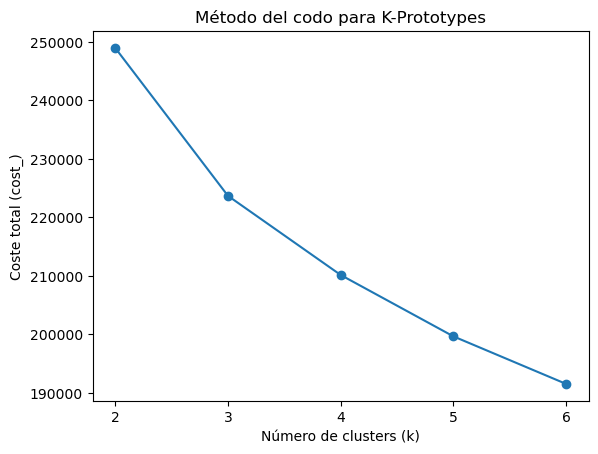

In [6]:
plt.plot(k_values, cost, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Coste total (cost_)")
plt.title("Método del codo para K-Prototypes")
plt.xticks(k_values)
plt.show()

In [12]:
kproto = KPrototypes(n_clusters=3, init='Huang', max_iter=50, random_state=42)
clusters = kproto.fit_predict(X, categorical=categorical_features_indices)

In [13]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform

def kprototypes_distance_matrix(X, categorical_features_indices, gamma):
    
    all_indices = np.arange(X.shape[1])
    num_mask = np.isin(all_indices, categorical_features_indices, invert=True)
    cat_mask = np.isin(all_indices, categorical_features_indices)
    
    X_num = X[:, num_mask]
    X_cat = X[:, cat_mask]
    
    encoder = OrdinalEncoder()
    X_cat_encoded = encoder.fit_transform(X_cat.astype(str)) 
    
    D_num = squareform(pdist(X_num.astype(float), metric='euclidean'))
    
    D_cat = squareform(pdist(X_cat_encoded, metric='hamming')) * X_cat.shape[1]
    
    D_combined = D_num + gamma * D_cat
    
    return D_combined

try:
    gamma_factor = kproto.gamma 
except NameError:
    gamma_factor = 1.0 

D = kprototypes_distance_matrix(X, categorical_features_indices, gamma=gamma_factor)

silhouette_avg = silhouette_score(D, clusters, metric='precomputed')

print(f"K-Prototypes (k=3) - Silhouette Score: {silhouette_avg:.3f}")
print(f"Usando factor gamma: {gamma_factor:.4f}")

K-Prototypes (k=3) - Silhouette Score: 0.138
Usando factor gamma: 0.5001


El factor gamma significa que después de normalizar, el algoritmo considera que los datos categóricos y los numéricos tienen un peso casi perfectamente equilibrado en la formación de los clusters.

Vemos que el silhouette es bajo, aunque es una pequeña mejora respecto al algoritmo de K-means aplicado a los datos numéricos o a los codificados con One Hot Encoding. También vemos que el número de clusters es menor.